In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from torch.utils.data import DataLoader, random_split
import torch
import sys
sys.path.append("..")
from src.utils import MoonsDataset
from src.models import MarginalDensityFlow
from functools import partial
from src.criticism import c2st, z_test
from src.data.toy_models import NormalNormal
from src.data.sir_model import SIRModel
from scipy.special import logit

mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


# Two Moons

In [2]:
N = 2000
a = int(N * 0.8)
b = N - a
dataset = MoonsDataset(n_sample=N, random_state=3)
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

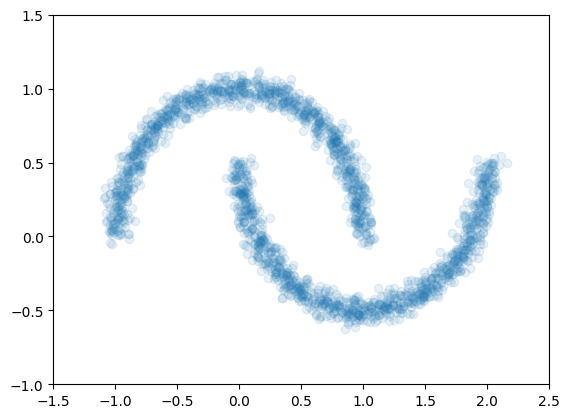

In [3]:
m = np.array(dataset.data)
plt.scatter(m[:, 0], m[:, 1], alpha=0.1)
plt.xlim(-1.5, 2.5)
plt.ylim(-1, 1.5)
plt.show()

In [4]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(2, 3, flow_type="NSF", optimizer=optim)
trainer = L.Trainer(max_epochs=200, log_every_n_steps=1)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | NSF      | 22.0 K | train
-------------------------------------------
22.0 K    Trainable params
0         Non-trainable params
22.0 K    Total params
0.088     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [5]:
samples = model.flow().sample((1000,))

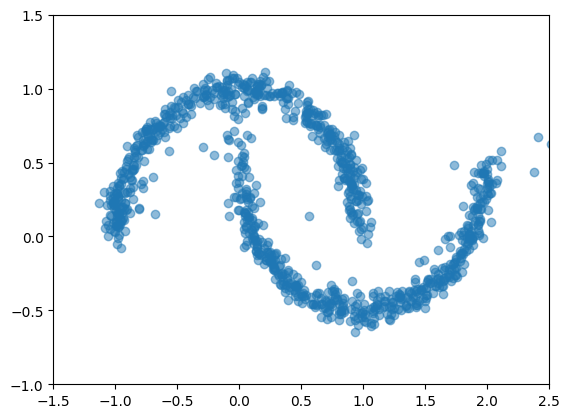

In [6]:
plt.scatter(*samples.T, alpha=0.5)
plt.xlim(-1.5, 2.5)
plt.ylim(-1, 1.5)
plt.show()

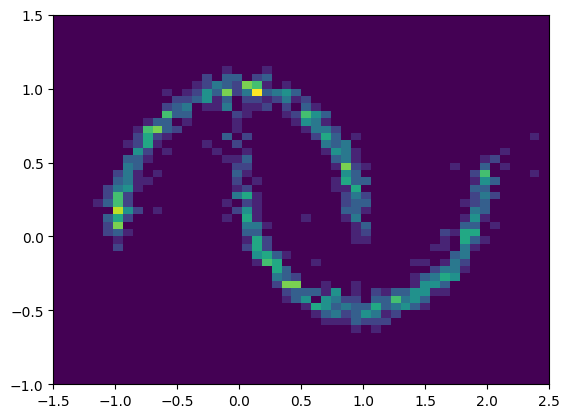

In [7]:
extra_samples = model.flow().sample((10000,))
plt.hist2d(*samples.T, bins=50, range = ((-1.5, 2.5), (-1, 1.5)))
plt.show()

## 2-Sample Classification Test

In [18]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val, samples)

Predicting: |                                                       | 0/? [00:00<?, ?it/s]

tensor(0.5287, dtype=torch.float64)

# Normal-Normal

In [57]:
N = 2000
a = int(N * 0.8)
b = N - a
dataset = NormalNormal(N=100, prior_mu=0, prior_sigma=5, dim=2, n_sample=N, true_sigma=1.414, observed_seed=11,
                      false_sigma=1)
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

In [58]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(4, 3, flow_type="MAF", optimizer=optim)
trainer = L.Trainer(max_epochs=200, log_every_n_steps=1)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 15.0 K | train
-------------------------------------------
15.0 K    Trainable params
0         Non-trainable params
15.0 K    Total params
0.060     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [59]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val, samples)

Predicting: |                                                       | 0/? [00:00<?, ?it/s]

tensor(0.5350, dtype=torch.float64)

In [62]:
observed_data = dataset.get_observed_data()
_, marginal_log_likelihood = model.predict_step(observed_data)
z_test(mll_val, marginal_log_likelihood)

(tensor(0.), tensor(True))

In [63]:
observed_data

tensor([[3.8522, 9.5625, 2.3572, 2.3889]])

# SIR Model

## Setting up Target Data

In [2]:
N = 4000
a = int(N * 0.8)
b = N - a

In [3]:
dataset = SIRModel(beta=1.5, gamma=.5, prior_scale=[1, 1], N=100, T=10, observed_seed=9, n_sample=N, partial_obs=True,
                  mode="criticism", noise="normal")
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

In [29]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 3, flow_type="NSF", optimizer=optim)
trainer = L.Trainer(max_epochs=200, log_every_n_steps=1)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | NSF      | 59.4 K | train
-------------------------------------------
59.4 K    Trainable params
0         Non-trainable params
59.4 K    Total params
0.238     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [30]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples, noise_scale=0.1)

Predicting: |                                                               | 0/? [00:00<?, ?it/s]

tensor(0.5744, dtype=torch.float64)

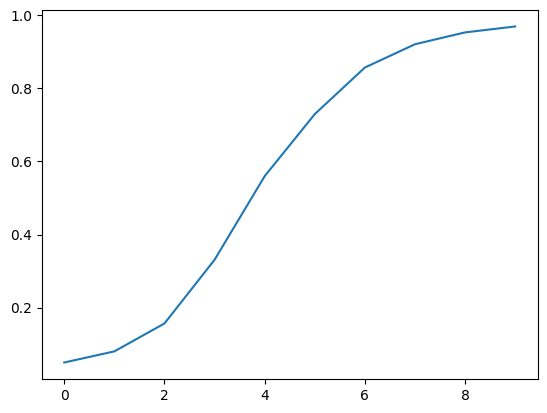

In [31]:
x_o = dataset.get_observed_data()
plt.plot(x_o[0][0])
plt.show()

In [12]:
x_val.shape

torch.Size([800, 1, 10])

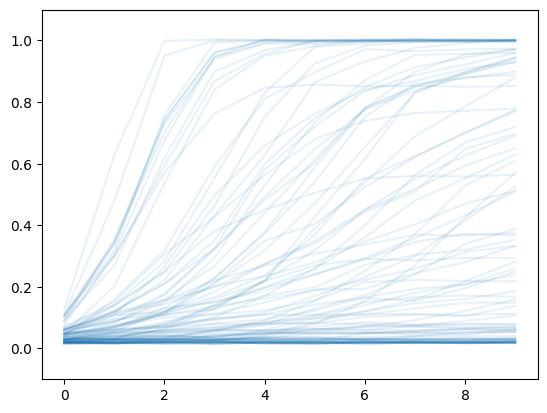

In [32]:
plt.plot(x_val[:100, 0, :].T, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

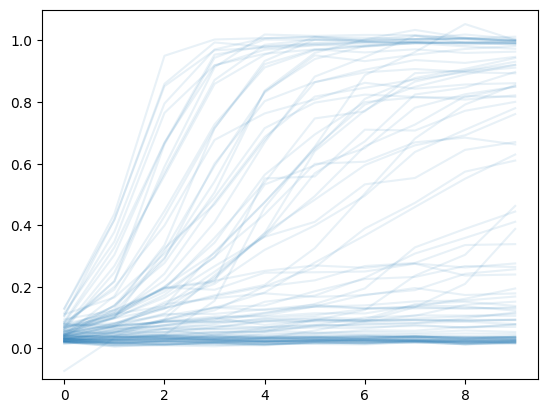

In [33]:
plt.plot(samples[:100, :].T, alpha=0.1, color="tab:blue")
plt.ylim(-0.1, 1.1)
plt.show()

In [34]:
# what's the right view of the data? Cumulative infections? Or number of new infections?

In [41]:
torch.diff(x_val.squeeze(1)[:10], 1)

tensor([[ 6.4404e-03, -1.0110e-03,  1.7015e-02,  7.5879e-03,  6.5817e-03,
         -2.6618e-03, -4.5099e-04,  1.4089e-03,  2.9035e-03],
        [-1.5178e-03,  8.3464e-03,  5.7943e-03, -8.2220e-03,  5.5482e-03,
         -2.2799e-05,  8.7877e-03,  1.4008e-02, -7.4878e-05],
        [ 3.9623e-03,  3.2214e-02,  3.6498e-02,  6.9522e-02,  9.0068e-02,
          1.3961e-01,  1.6307e-01,  1.0540e-01,  5.0703e-02],
        [ 1.7768e-02,  5.2232e-02,  6.4987e-02,  8.9080e-02,  6.7789e-02,
          1.0189e-01,  6.6923e-02,  1.3766e-01,  4.8818e-02],
        [-1.0640e-03, -9.6173e-04,  2.4238e-03,  1.1210e-04, -1.0783e-03,
         -8.3021e-04, -3.9902e-05,  1.6306e-03,  3.5069e-03],
        [-1.6594e-03,  1.5421e-03,  2.1710e-03, -3.4260e-03, -4.2244e-04,
         -2.4885e-03,  7.2922e-04,  8.6014e-04,  3.3731e-03],
        [ 3.9653e-03, -1.5034e-03, -4.0650e-04,  4.9538e-03,  2.4146e-03,
         -6.6579e-03,  1.2558e-03, -1.7504e-03,  2.0522e-03],
        [ 1.8914e-01,  2.6918e-01,  1.9207e-01, 

In [44]:
x_diff = x_val.squeeze(1).diff()

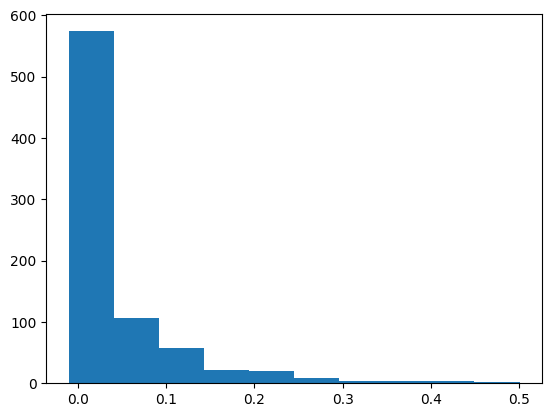

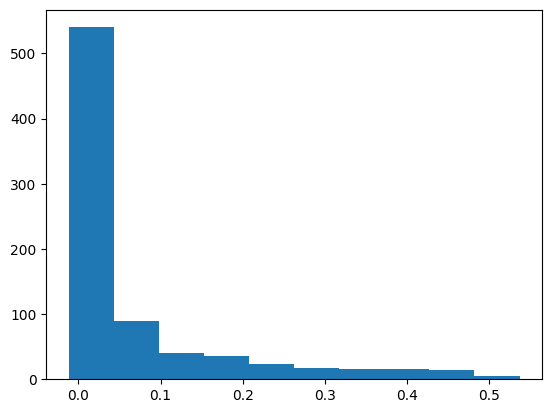

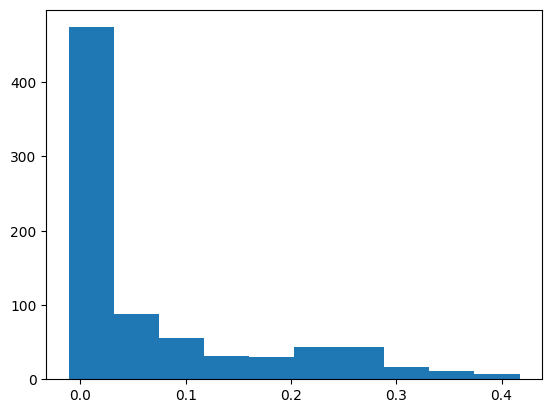

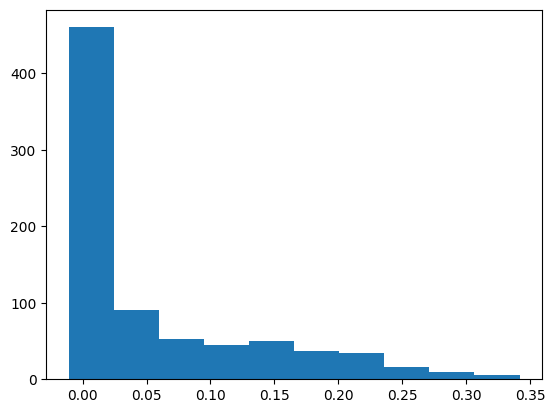

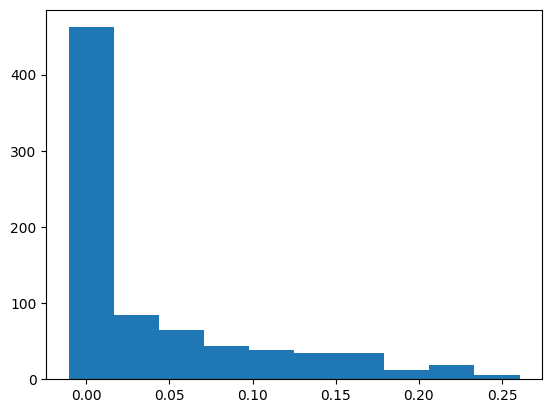

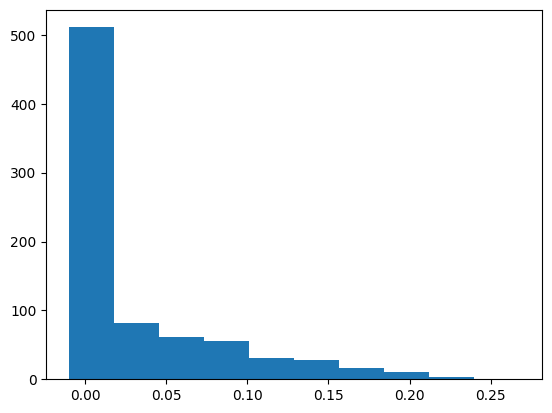

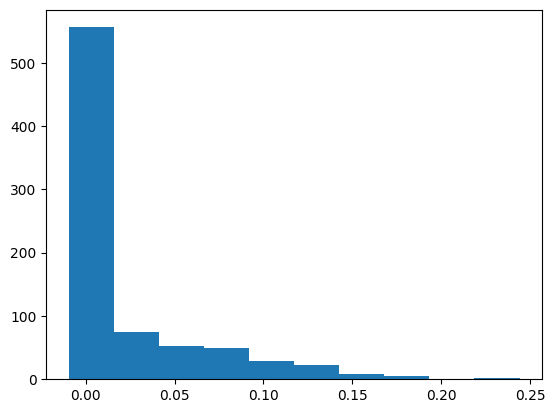

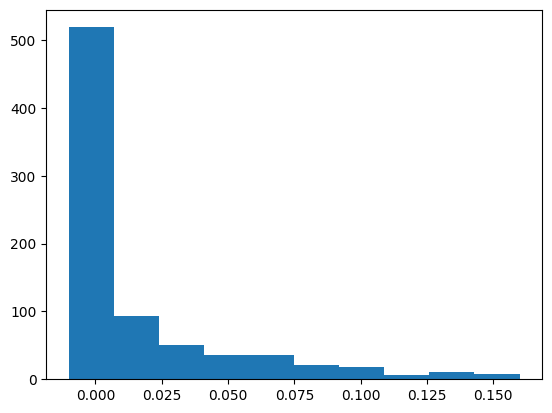

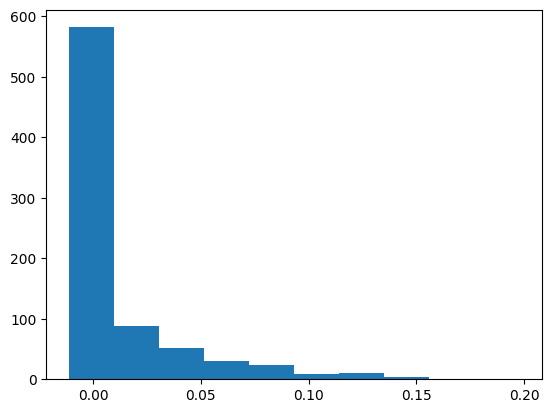

In [46]:
for i in range(9):
    plt.hist(x_diff[:, i])
    plt.show()

In [43]:
x_val.squeeze(1)[0]

tensor([0.0176, 0.0240, 0.0230, 0.0400, 0.0476, 0.0542, 0.0515, 0.0511, 0.0525,
        0.0554])